In [5]:
import bff

from pathlib import Path

In [6]:
learning_dir = Path('../05-learning').resolve()
trainset_dir = Path('../03-training-trjs/c36-ecc80-00').resolve()

fn_posterior = learning_dir / 'posterior.pt'
fn_specs = trainset_dir / 'specs.yaml'
fn_priors = learning_dir / 'priors.pt'

specs = bff.domain.Specs(fn_specs)
results = bff.bayes.results.InferenceResults.load(
    posterior=fn_posterior,
    priors=fn_priors,
)

marginal_labels = [
    name.split(maxsplit=1)[-1] for name in specs.bounds.names.tolist()
]
explicit_param_names = list(specs.parameter_names(explicit_only=True))
explicit_labels = [
    name.split(maxsplit=1)[-1] for name in explicit_param_names
]
nuisance_labels = [
    f"$\\sigma_{{\\mathrm{{{name.removeprefix('log_sigma_')}}}}}$"
    for name in results.priors.names
    if name.startswith('log_sigma_')
]
corner_labels = explicit_labels + nuisance_labels

In [7]:
# Prepare posterior samples for visualization.
# This acetate example uses a short chain, so keep all saved samples.
results.prepare_samples(discard=0, thin=1)

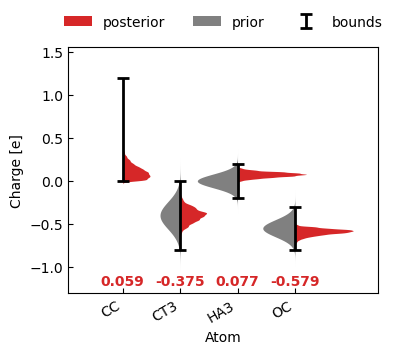

In [8]:
bff.plotting.plot_marginals(
    results,
    specs,
    parameter_labels=marginal_labels,
)

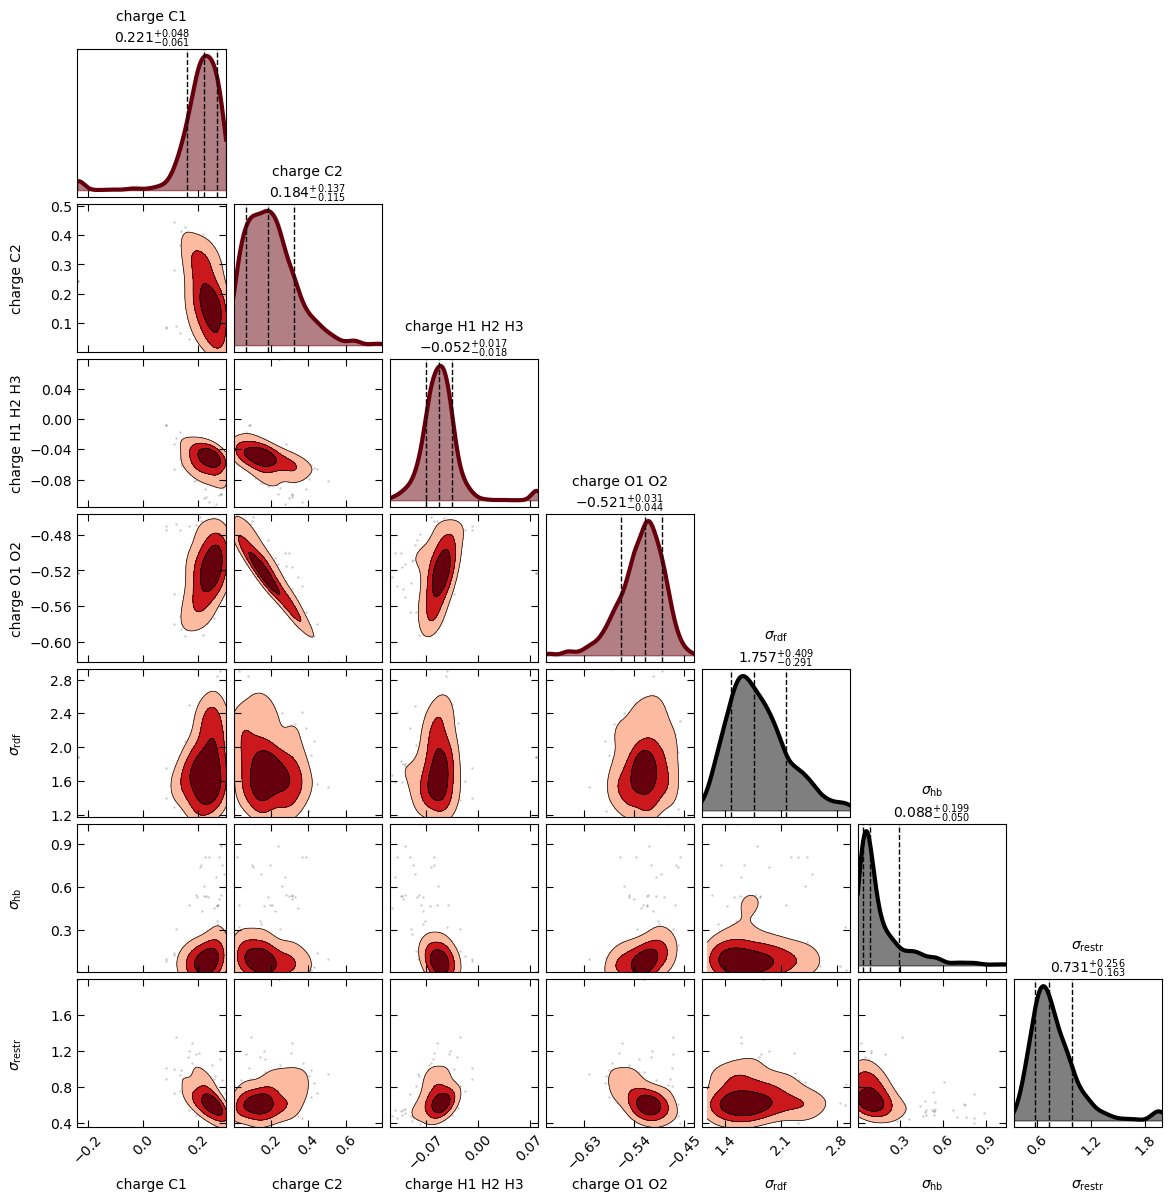

In [11]:
bff.plotting.plot_corner(results, labels=corner_labels)

In [6]:
# Save posterior samples
samples = results.sample_posterior(
    10,
    fn_out='./posterior-samples.yaml',
    overwrite=True,
)

In [24]:
# Modify and save a topology file with the first posterior sample
fn_top = trainset_dir / 'window-000.top'
top = bff.topology.TopologyModifier(
    fn_top,
    specs.mol_resname,
    specs.implicit_atoms
)

n_explicit = len(explicit_param_names)
new_params = dict(zip(explicit_param_names, samples[0][:n_explicit]))
top.apply_parameters(new_params, constraint_charge=None)
top.write('./topol-sample-001.top', overwrite=True)